
**Introduction**

This dataset contains detailed information about flight bookings and pricing in Bangladesh. It includes data on airlines, flight routes, departure and arrival times, ticket prices, and other relevant attributes. The dataset is structured with 57,000 rows and 19 columns, providing a comprehensive view of flight operations and pricing trends.

**Objective**
The dataset can be used for various analyses, such as:
- Understanding pricing trends and factors affecting ticket prices.
- Identifying the most and least expensive airlines and routes.
- Analyzing the impact of seasonality on flight prices.
- Exploring customer preferences for booking sources and flight classes.

This dataset is ideal for data cleaning, exploratory data analysis (EDA), and predictive modeling tasks, such as forecasting ticket prices or identifying factors influencing flight costs.


Import necessary library

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import warnings 
import re

import dataset

In [2]:
df=pd.read_csv(r'C:\Users\abhinand\Downloads\flightprice\Flight_Price_Dataset_of_Bangladesh.csv')



Extracting first 10 rows

In [3]:
df.head(10)

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90
5,IndiGo,ZYL,"Osmani International Airport, Sylhet",SPD,Saidpur Airport,2025-06-18 18:28:00,2025-06-18 19:33:06,1.085066,Direct,Airbus A320,Business,Travel Agency,5036.394160,200.000000,5236.394160,Regular,70
6,US-Bangla Airlines,SPD,Saidpur Airport,BZL,Barisal Airport,2025-10-25 22:41:00,2025-10-25 23:45:41,1.078155,Direct,Airbus A320,Business,Direct Booking,7397.669874,200.000000,7597.669874,Regular,28
7,AirAsia,JSR,Jessore Airport,LHR,London Heathrow Airport,2025-12-28 01:38:00,2025-12-28 10:30:49,8.880376,1 Stop,Airbus A350,Economy,Online Website,11946.813583,7792.022037,19738.835620,Winter Holidays,12
8,Etihad Airways,SPD,Saidpur Airport,KUL,Kuala Lumpur International Airport,2025-07-06 21:52:00,2025-07-07 01:09:46,3.296282,Direct,Boeing 787,Business,Travel Agency,74973.621871,17246.043281,92219.665152,Regular,23
9,US-Bangla Airlines,DAC,"Hazrat Shahjalal International Airport, Dhaka",DEL,"Indira Gandhi International Airport, Delhi",2025-04-14 23:19:00,2025-04-15 01:54:44,2.595620,Direct,Boeing 787,First Class,Direct Booking,116951.645445,19542.746817,136494.392261,Regular,41


Extracting last 10 rows

In [4]:
df.tail(10)

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
56990,Biman Bangladesh Airlines,DAC,"Hazrat Shahjalal International Airport, Dhaka",DOH,"Hamad International Airport, Doha",2025-03-14 23:48:00,2025-03-15 03:46:21,3.972507,Direct,Boeing 787,First Class,Direct Booking,38531.545695,9779.731854,48311.277549,Regular,42
56991,British Airways,RJH,"Shah Makhdum Airport, Rajshahi",YYZ,Toronto Pearson International Airport,2025-03-02 09:51:00,2025-03-02 22:44:37,12.893848,1 Stop,Airbus A350,Economy,Travel Agency,27622.217394,10143.332609,37765.550003,Regular,39
56992,NovoAir,CGP,"Shah Amanat International Airport, Chittagong",JFK,"John F. Kennedy International Airport, New York",2025-09-27 10:34:00,2025-09-28 00:49:11,14.253156,1 Stop,Airbus A350,Economy,Direct Booking,34824.609573,11223.691436,46048.301009,Regular,32
56993,Singapore Airlines,ZYL,"Osmani International Airport, Sylhet",DXB,Dubai International Airport,2025-10-26 06:55:00,2025-10-26 11:08:17,4.221616,Direct,Boeing 737,First Class,Travel Agency,261460.041124,43219.006169,304679.047292,Regular,41
56994,British Airways,SPD,Saidpur Airport,JFK,"John F. Kennedy International Airport, New York",2025-11-05 12:16:00,2025-11-06 01:55:15,13.654421,1 Stop,Airbus A350,Economy,Direct Booking,24943.146984,9741.472048,34684.619031,Regular,6
56995,Kuwait Airways,JSR,Jessore Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-08-11 00:10:00,2025-08-11 00:40:00,0.500000,Direct,Airbus A320,Business,Online Website,79974.471748,13996.170762,93970.642511,Regular,51
56996,Kuwait Airways,CGP,"Shah Amanat International Airport, Chittagong",CCU,Netaji Subhas Chandra Bose International Airpo...,2025-09-19 23:53:00,2025-09-20 01:09:30,1.275145,Direct,Airbus A320,First Class,Online Website,193471.364277,31020.704642,224492.068918,Regular,31
56997,Biman Bangladesh Airlines,CXB,Cox's Bazar Airport,JSR,Jessore Airport,2025-11-08 09:23:00,2025-11-08 10:35:59,1.216583,Direct,Airbus A320,Economy,Direct Booking,4375.365554,200.000000,4575.365554,Regular,22
56998,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-11-25 10:23:00,2025-11-26 00:20:37,13.960502,1 Stop,Airbus A350,Economy,Direct Booking,40903.602688,12135.540403,53039.143091,Regular,20
56999,Air India,DAC,"Hazrat Shahjalal International Airport, Dhaka",RJH,"Shah Makhdum Airport, Rajshahi",2025-07-05 04:12:00,2025-07-05 04:50:55,0.648755,Direct,Airbus A320,Business,Direct Booking,5831.070839,200.000000,6031.070839,Regular,6


Takeing column info

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airline                57000 non-null  object 
 1   Source                 57000 non-null  object 
 2   Source Name            57000 non-null  object 
 3   Destination            57000 non-null  object 
 4   Destination Name       57000 non-null  object 
 5   Departure Date & Time  57000 non-null  object 
 6   Arrival Date & Time    57000 non-null  object 
 7   Duration (hrs)         57000 non-null  float64
 8   Stopovers              57000 non-null  object 
 9   Aircraft Type          57000 non-null  object 
 10  Class                  57000 non-null  object 
 11  Booking Source         57000 non-null  object 
 12  Base Fare (BDT)        57000 non-null  float64
 13  Tax & Surcharge (BDT)  57000 non-null  float64
 14  Total Fare (BDT)       57000 non-null  float64
 15  Se

**Data cleaning**
Removing null values
Datatype changing
Removing space and symbol 

In [6]:
df['Departure Date & Time']=pd.to_datetime(df['Departure Date & Time'])
df['Duration (hrs)']=df['Duration (hrs)'].round()
df.columns = df.columns.str.replace(r'[()\[\]{}]', '', regex=True).str.replace(' ', '_')

print(df.columns)


Index(['Airline', 'Source', 'Source_Name', 'Destination', 'Destination_Name',
       'Departure_Date_&_Time', 'Arrival_Date_&_Time', 'Duration_hrs',
       'Stopovers', 'Aircraft_Type', 'Class', 'Booking_Source',
       'Base_Fare_BDT', 'Tax_&_Surcharge_BDT', 'Total_Fare_BDT', 'Seasonality',
       'Days_Before_Departure'],
      dtype='object')


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Airline                57000 non-null  object        
 1   Source                 57000 non-null  object        
 2   Source_Name            57000 non-null  object        
 3   Destination            57000 non-null  object        
 4   Destination_Name       57000 non-null  object        
 5   Departure_Date_&_Time  57000 non-null  datetime64[ns]
 6   Arrival_Date_&_Time    57000 non-null  object        
 7   Duration_hrs           57000 non-null  float64       
 8   Stopovers              57000 non-null  object        
 9   Aircraft_Type          57000 non-null  object        
 10  Class                  57000 non-null  object        
 11  Booking_Source         57000 non-null  object        
 12  Base_Fare_BDT          57000 non-null  float64       
 13  T

Taking columns name from dataset

In [8]:
df.columns

Index(['Airline', 'Source', 'Source_Name', 'Destination', 'Destination_Name',
       'Departure_Date_&_Time', 'Arrival_Date_&_Time', 'Duration_hrs',
       'Stopovers', 'Aircraft_Type', 'Class', 'Booking_Source',
       'Base_Fare_BDT', 'Tax_&_Surcharge_BDT', 'Total_Fare_BDT', 'Seasonality',
       'Days_Before_Departure'],
      dtype='object')

In [9]:
df.describe(include='object')

,Airline,Source,Source_Name,Destination,Destination_Name,Arrival_Date_&_Time,Stopovers,Aircraft_Type,Class,Booking_Source,Seasonality
count,57000,57000,57000,57000,57000,57000,57000,57000,57000,57000,57000
unique,24,8,8,20,20,56944,3,5,3,3,4
top,US-Bangla Airlines,CGP,"Shah Amanat International Airport, Chittagong",JED,"King Abdulaziz International Airport, Jeddah",2025-12-10 21:54:33,Direct,Airbus A320,Economy,Direct Booking,Regular
freq,4496,7241,7241,3071,3071,2,36642,23970,19112,19111,44525


Taking Number of Rows and column 

In [10]:
df.shape

(57000, 17)

Finding null values 

In [11]:
df.isnull().sum()

Airline                  0
Source                   0
Source_Name              0
Destination              0
Destination_Name         0
Departure_Date_&_Time    0
Arrival_Date_&_Time      0
Duration_hrs             0
Stopovers                0
Aircraft_Type            0
Class                    0
Booking_Source           0
Base_Fare_BDT            0
Tax_&_Surcharge_BDT      0
Total_Fare_BDT           0
Seasonality              0
Days_Before_Departure    0
dtype: int64

Taking All unique Airlines 

In [12]:
for col in df.describe(include='object').columns:
    print(col)
    print(df[col].unique())
    print('-'*50)
    

Airline
['Malaysian Airlines' 'Cathay Pacific' 'British Airways'
 'Singapore Airlines' 'IndiGo' 'US-Bangla Airlines' 'AirAsia'
 'Etihad Airways' 'Gulf Air' 'Emirates' 'Biman Bangladesh Airlines'
 'NovoAir' 'FlyDubai' 'Saudia' 'Thai Airways' 'Kuwait Airways' 'Air India'
 'Air Astra' 'Qatar Airways' 'Air Arabia' 'SriLankan Airlines' 'Vistara'
 'Lufthansa' 'Turkish Airlines']
--------------------------------------------------
Source
['CXB' 'BZL' 'ZYL' 'RJH' 'SPD' 'JSR' 'DAC' 'CGP']
--------------------------------------------------
Source_Name
["Cox's Bazar Airport" 'Barisal Airport'
 'Osmani International Airport, Sylhet' 'Shah Makhdum Airport, Rajshahi'
 'Saidpur Airport' 'Jessore Airport'
 'Hazrat Shahjalal International Airport, Dhaka'
 'Shah Amanat International Airport, Chittagong']
--------------------------------------------------
Destination
['CCU' 'CGP' 'KUL' 'DAC' 'YYZ' 'SPD' 'BZL' 'LHR' 'DEL' 'ZYL' 'RJH' 'JSR'
 'CXB' 'IST' 'DXB' 'SIN' 'BKK' 'DOH' 'JFK' 'JED']
-----------------

In [13]:
df.describe()

,Duration_hrs,Base_Fare_BDT,Tax_&_Surcharge_BDT,Total_Fare_BDT,Days_Before_Departure
count,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000
mean,3.981246,58899.556573,11448.238494,71030.316199,45.460579
std,4.111639,68840.614499,12124.344329,81769.199536,26.015657
min,0.000000,1600.975688,200.000000,1800.975688,1.000000
25%,1.000000,8856.316983,200.000000,9602.699787,23.000000
50%,3.000000,31615.996792,9450.940481,41307.544990,45.000000
75%,5.000000,85722.930389,17513.046160,103800.906963,68.000000
max,16.000000,449222.933770,73383.440066,558987.332444,90.000000



How many unique airlines are operating in the dataset?

Number of Unique Airlines

In [14]:
df["Airline"].nunique()


24

To list the unique airlines

In [15]:
df["Airline"].unique() 


array(['Malaysian Airlines', 'Cathay Pacific', 'British Airways',
       'Singapore Airlines', 'IndiGo', 'US-Bangla Airlines', 'AirAsia',
       'Etihad Airways', 'Gulf Air', 'Emirates',
       'Biman Bangladesh Airlines', 'NovoAir', 'FlyDubai', 'Saudia',
       'Thai Airways', 'Kuwait Airways', 'Air India', 'Air Astra',
       'Qatar Airways', 'Air Arabia', 'SriLankan Airlines', 'Vistara',
       'Lufthansa', 'Turkish Airlines'], dtype=object)

How does the total fare vary with the number of days before departure?

<Axes: title={'center': 'Price vs. Days_Before_Departure'}, xlabel='Days_Before_Departure'>

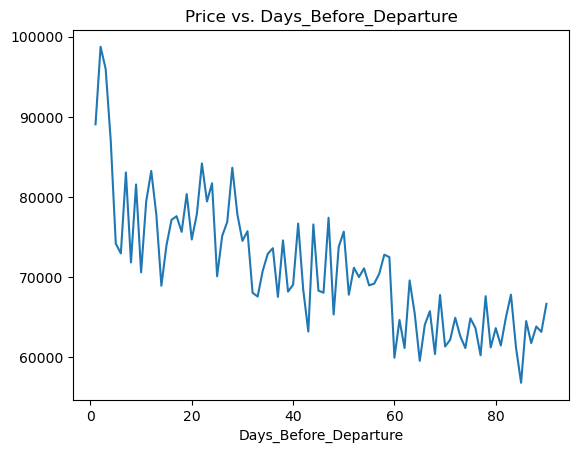

In [16]:
df.groupby("Days_Before_Departure")["Total_Fare_BDT"].mean().plot(kind="line", title="Price vs. Days_Before_Departure")


Which booking source (Online Website, Travel Agency, Direct Booking) offers the lowest average fare?

In [17]:
df.groupby("Booking_Source")["Total_Fare_BDT"].mean().sort_values()


Booking_Source
Travel Agency     70934.152325
Direct Booking    71018.669179
Online Website    71137.998113
Name: Total_Fare_BDT, dtype: float64

What is the impact of seasonality (Regular, Winter Holidays, etc.) on flight prices?

In [18]:
df.groupby("Seasonality")["Total_Fare_BDT"].mean().sort_values()


Seasonality
Regular            68077.271029
Winter Holidays    79676.737877
Eid                91560.023236
Hajj               97144.471058
Name: Total_Fare_BDT, dtype: float64

Which airlines have the highest and lowest average ticket prices?

In [19]:
df.groupby("Airline")["Total_Fare_BDT"].mean().sort_values()


Airline
Vistara                      68108.238844
Singapore Airlines           68323.930914
NovoAir                      68350.859248
Air Astra                    68497.407804
FlyDubai                     68987.689206
Saudia                       69270.676123
Lufthansa                    69293.163879
Qatar Airways                69865.536487
Air Arabia                   69924.006965
Emirates                     70106.149413
Biman Bangladesh Airlines    70192.969287
British Airways              70555.536205
SriLankan Airlines           71265.261154
Gulf Air                     71458.163828
Etihad Airways               71785.242045
Kuwait Airways               71988.276107
US-Bangla Airlines           72088.289025
Air India                    72474.178419
IndiGo                       72504.433122
Malaysian Airlines           72775.180201
Thai Airways                 72845.789993
Cathay Pacific               73325.091124
AirAsia                      74534.390651
Turkish Airlines          

 Top 5 Most Expensive and Cheapest Flights

In [20]:
df.nlargest(5, "Total_Fare_BDT")  # Top 5 most expensive
df.nsmallest(5, "Total_Fare_BDT")  # Top 5 cheapest


,Airline,Source,Source_Name,Destination,Destination_Name,Departure_Date_&_Time,Arrival_Date_&_Time,Duration_hrs,Stopovers,Aircraft_Type,Class,Booking_Source,Base_Fare_BDT,Tax_&_Surcharge_BDT,Total_Fare_BDT,Seasonality,Days_Before_Departure
45427,NovoAir,RJH,"Shah Makhdum Airport, Rajshahi",SPD,Saidpur Airport,2025-10-12 14:59:00,2025-10-12 15:29:00,0.0,Direct,Airbus A320,Economy,Online Website,1600.975688,200.0,1800.975688,Regular,60
41356,US-Bangla Airlines,ZYL,"Osmani International Airport, Sylhet",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-07-15 11:31:00,2025-07-15 12:10:10,1.0,Direct,Airbus A320,Economy,Direct Booking,1601.196913,200.0,1801.196913,Regular,83
25991,AirAsia,CXB,Cox's Bazar Airport,JSR,Jessore Airport,2025-11-14 01:51:00,2025-11-14 02:55:34,1.0,Direct,Airbus A320,Economy,Direct Booking,1604.132096,200.0,1804.132096,Regular,86
18063,Cathay Pacific,DAC,"Hazrat Shahjalal International Airport, Dhaka",BZL,Barisal Airport,2025-11-20 07:58:00,2025-11-20 08:28:00,0.0,Direct,Airbus A320,Economy,Direct Booking,1605.890639,200.0,1805.890639,Regular,73
19224,Air Arabia,ZYL,"Osmani International Airport, Sylhet",CXB,Cox's Bazar Airport,2025-11-24 08:21:00,2025-11-24 09:38:20,1.0,Direct,Airbus A320,Economy,Direct Booking,1605.984292,200.0,1805.984292,Regular,84


Plot the distribution of Total Fare (BDT)

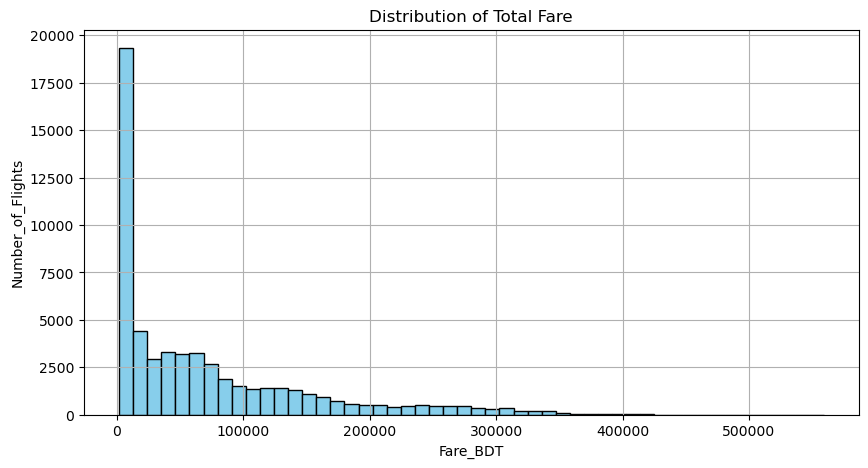

In [21]:


plt.figure(figsize=(10, 5))
plt.hist(df["Total_Fare_BDT"], bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of Total Fare")
plt.xlabel("Fare_BDT")
plt.ylabel("Number_of_Flights")
plt.grid(True)
plt.show()


Show average fare for each airline using a bar chart



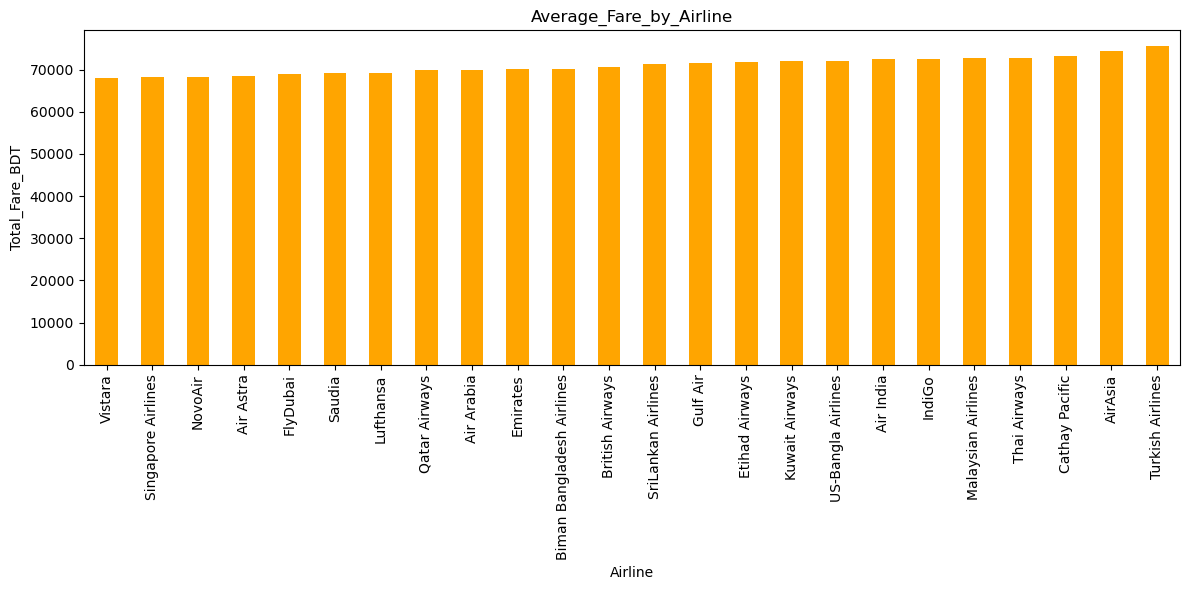

In [22]:
avg_fare = df.groupby("Airline")["Total_Fare_BDT"].mean().sort_values()

plt.figure(figsize=(12, 6))
avg_fare.plot(kind="bar", color="orange")
plt.title("Average_Fare_by_Airline")
plt.ylabel("Total_Fare_BDT")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


Create a pie chart of flight class distribution

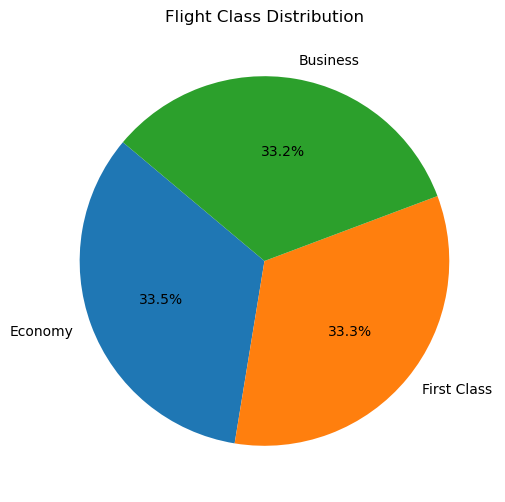

In [23]:
class_counts = df["Class"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Flight Class Distribution")
plt.show()


Line plot: Monthly flight counts

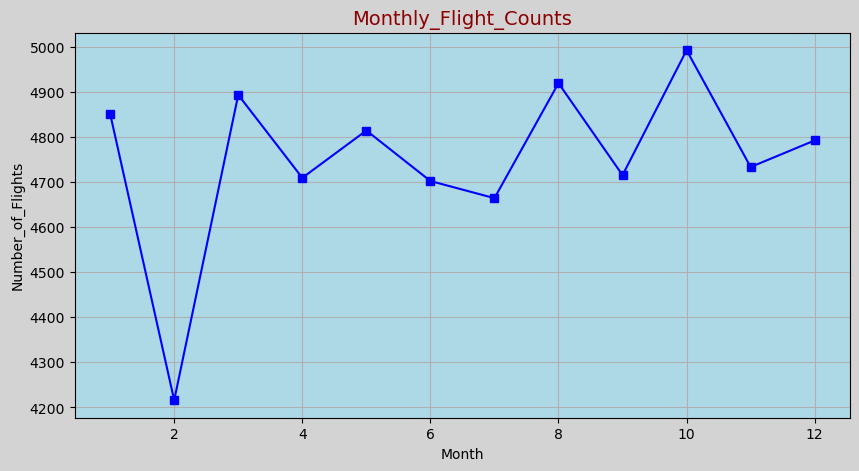

In [24]:

df["Departure_Date_&_Time"] = pd.to_datetime(df["Departure_Date_&_Time"])
df["Month"] = df["Departure_Date_&_Time"].dt.month
monthly_flight_counts = df["Month"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor("lightblue")  
fig.patch.set_facecolor("lightgray")
monthly_flight_counts.plot(kind="line", marker='s', color="blue", ax=ax)
ax.set_title("Monthly_Flight_Counts", color="darkred", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Number_of_Flights")
ax.grid(True)

plt.show()



Scatter plot: Duration vs Total Fare

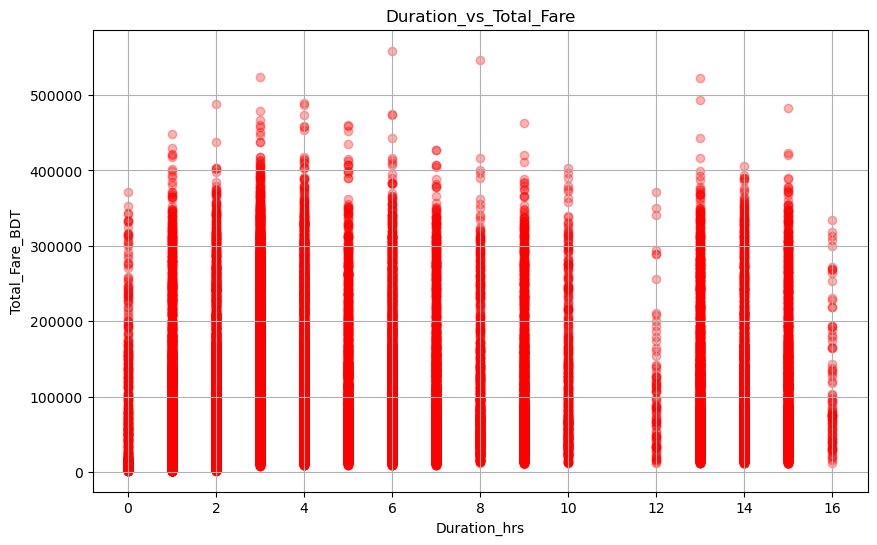

In [25]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Duration_hrs"], df["Total_Fare_BDT"], alpha=0.3, color="red")
plt.title("Duration_vs_Total_Fare")
plt.xlabel("Duration_hrs")
plt.ylabel("Total_Fare_BDT")
plt.grid(True)
plt.show()


Most expensive route on average

In [26]:
df['Route'] = df['Source'] + " to " + df['Destination']
df.groupby('Route')['Total_Fare_BDT'].mean().sort_values(ascending=False).head(5)

Route
SPD to BKK    117951.572347
CXB to YYZ    117848.709744
CXB to LHR    116667.654377
CXB to JFK    116476.311601
BZL to JFK    115968.436285
Name: Total_Fare_BDT, dtype: float64

**Scatter plot**: Base Fare vs Tax

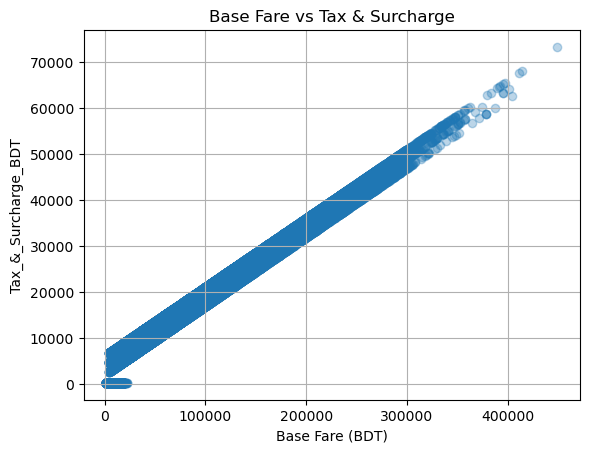

In [27]:
plt.scatter(df["Base_Fare_BDT"], df["Tax_&_Surcharge_BDT"], alpha=0.3)
plt.title("Base Fare vs Tax & Surcharge")
plt.xlabel("Base Fare (BDT)")
plt.ylabel("Tax_&_Surcharge_BDT")
plt.grid(True)
plt.show()


Fare Distribution by Class

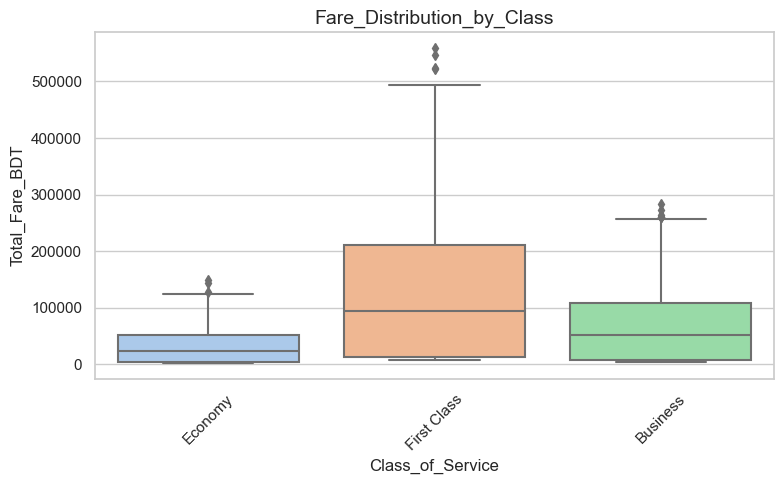

In [28]:

sns.set(style="whitegrid")

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Class', y='Total_Fare_BDT', palette='pastel')

plt.title('Fare_Distribution_by_Class', fontsize=14)
plt.xlabel('Class_of_Service')
plt.ylabel('Total_Fare_BDT')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


Price trend over time

<Axes: title={'center': 'Flight_Price_Trend_Over_Time'}, xlabel='Date'>

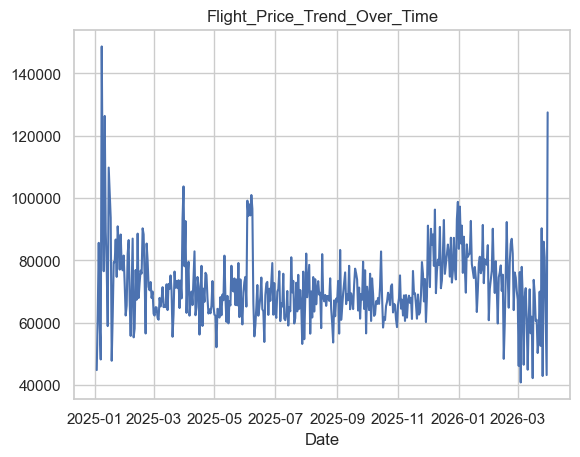

In [29]:
df['Date'] = pd.to_datetime(df['Departure_Date_&_Time']).dt.date
df.groupby('Date')['Total_Fare_BDT'].mean().plot(title='Flight_Price_Trend_Over_Time')


**Bar chart**: Average fare by seasonality

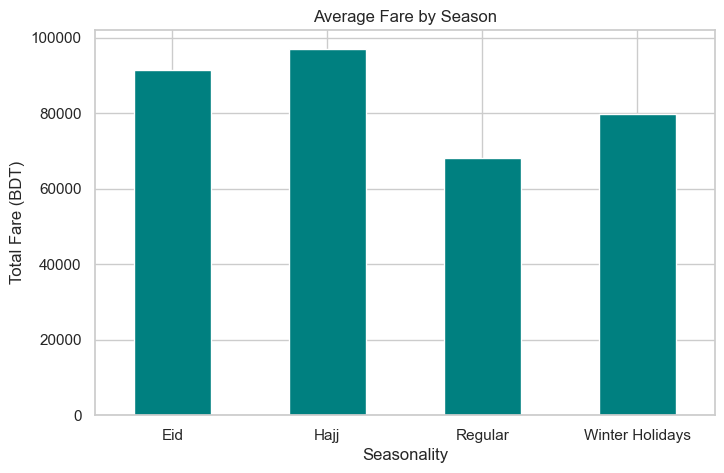

In [30]:
season_fares = df.groupby("Seasonality")["Total_Fare_BDT"].mean()

plt.figure(figsize=(8, 5))
season_fares.plot(kind="bar", color="teal")
plt.title("Average Fare by Season")
plt.ylabel("Total Fare (BDT)")
plt.xticks(rotation=0)
plt.grid(True)
plt.show()



prepare Features and Target

In [31]:

features = ["Days_Before_Departure", "Duration_hrs", "Base_Fare_BDT", "Tax_&_Surcharge_BDT"]

target = "Total_Fare_BDT"

X = df[features]
y = df[target]

print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())


Features (X):
   Days_Before_Departure  Duration_hrs  Base_Fare_BDT  Tax_&_Surcharge_BDT
0                     10           1.0   21131.225021          5169.683753
1                     14           1.0   11605.395471           200.000000
2                     83           3.0   39882.499349         11982.374902
3                     56           1.0    4435.607340           200.000000
4                     90          14.0   59243.806146         14886.570922

Target (y):
0    26300.908775
1    11805.395471
2    51864.874251
3     4635.607340
4    74130.377068
Name: Total_Fare_BDT, dtype: float64


**Project Summary: Flight Price Analysis and Prediction**

This project involves analyzing and predicting flight prices using a dataset containing detailed information about flight bookings and pricing in Bangladesh. The dataset includes 57,000 rows and 19 columns, providing insights into various factors affecting flight prices.

Key Objectives:
1. **Data Cleaning and Preprocessing**:
    - Removed null values and standardized column names.
    - Converted date columns to datetime format and rounded numerical values for better analysis.

2. **Exploratory Data Analysis (EDA)**:
    - Analyzed the distribution of flight prices and other attributes.
    - Identified trends and patterns, such as the impact of seasonality, booking source, and days before departure on ticket prices.
    - Visualized data using histograms, bar charts, pie charts, scatter plots, and line plots.

4. **Insights**:
    - **Seasonality**: Prices are highest during Hajj and Eid seasons.
    - **Booking Source**: Online websites offer the lowest average fares.
    - **Airlines**: Identified airlines with the highest and lowest average ticket prices.
    - **Routes**: Determined the most expensive routes on average.

5. **Visualization Highlights**:
    - Distribution of total fare.
    - Average fare by airline and seasonality.
    - Monthly flight counts and price trends over time.
    - Relationship between duration and total fare.

**Future Work**
- Build and evaluate machine learning models for price prediction.
- Perform hyperparameter tuning to improve model accuracy.
- Explore additional features and advanced techniques for better predictions.